In [2]:
import sys
sys.path.append("../")

from src.preprocessing import load_audio, audio_to_mel_segments

In [104]:
from src.preprocessing import process_and_save_file

In [6]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [106]:
audio_path = "../data/raw/genres_original/blues/blues.00000.wav"

audio, sample_rate = librosa.load(audio_path, sr=None)

In [107]:
audio

array([ 0.00732422,  0.01660156,  0.00762939, ..., -0.05560303,
       -0.06106567, -0.06417847], shape=(661794,), dtype=float32)

In [108]:
print("Sample rate : ", sample_rate)
print("Number of samples : ", len(audio))
print("Duration : ", len(audio)/sample_rate, "seconds")

Sample rate :  22050
Number of samples :  661794
Duration :  30.013333333333332 seconds


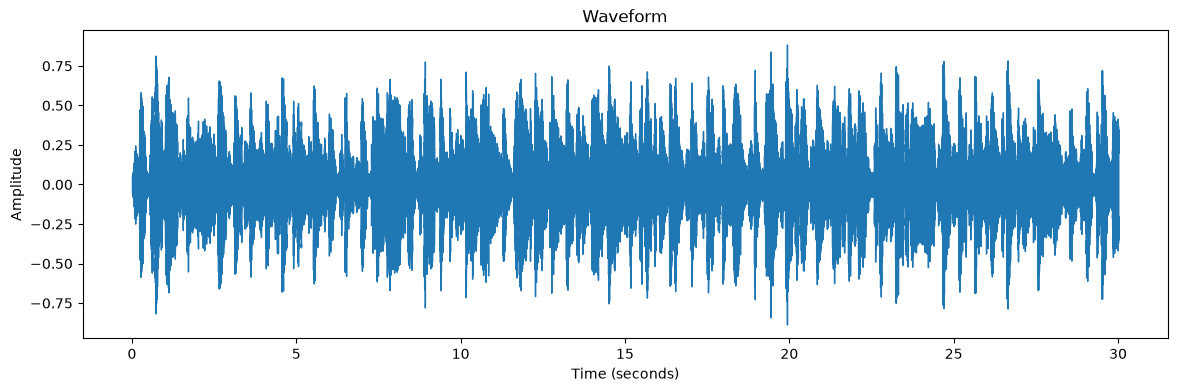

In [109]:
plt.figure(figsize=(14, 4))
librosa.display.waveshow(audio, sr=sample_rate)

plt.title("Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

In [110]:
stft = librosa.stft(audio)

print("STFT shape : ", stft.shape)

STFT shape :  (1025, 1293)


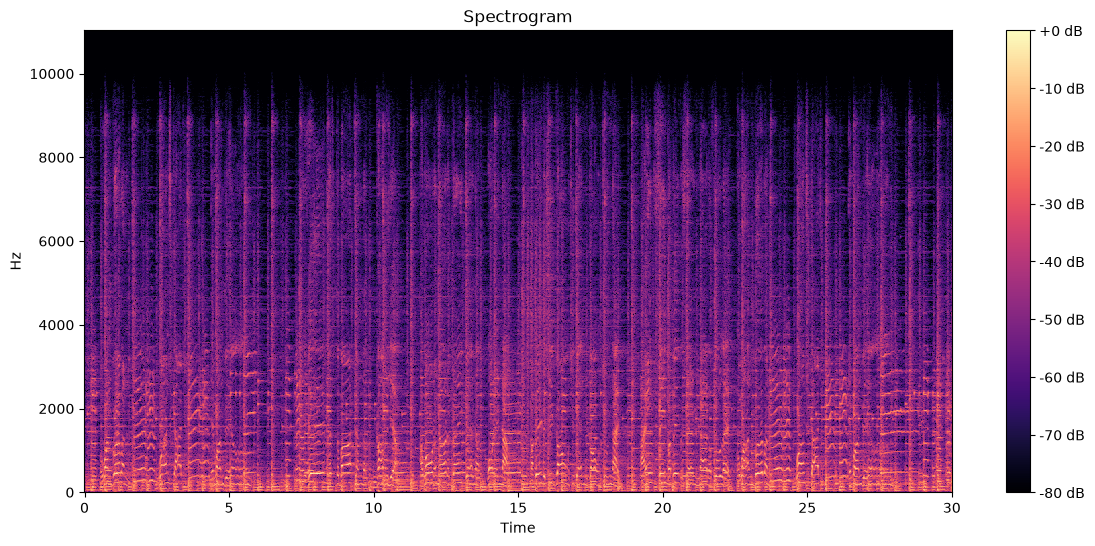

In [111]:
spectrogram = np.abs(stft)

plt.figure(figsize=(14, 6))

librosa.display.specshow(
    librosa.amplitude_to_db(spectrogram, ref=np.max),
    sr=sample_rate,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.show()

In [112]:
mel_spectrogram = librosa.feature.melspectrogram(
    y = audio,
    sr = sample_rate,
    n_fft = 2048,
    hop_length=512,
    n_mels=128
)

print(mel_spectrogram.shape)

(128, 1293)


In [113]:
mel_db = librosa.power_to_db(
    mel_spectrogram,
    ref=np.max
)

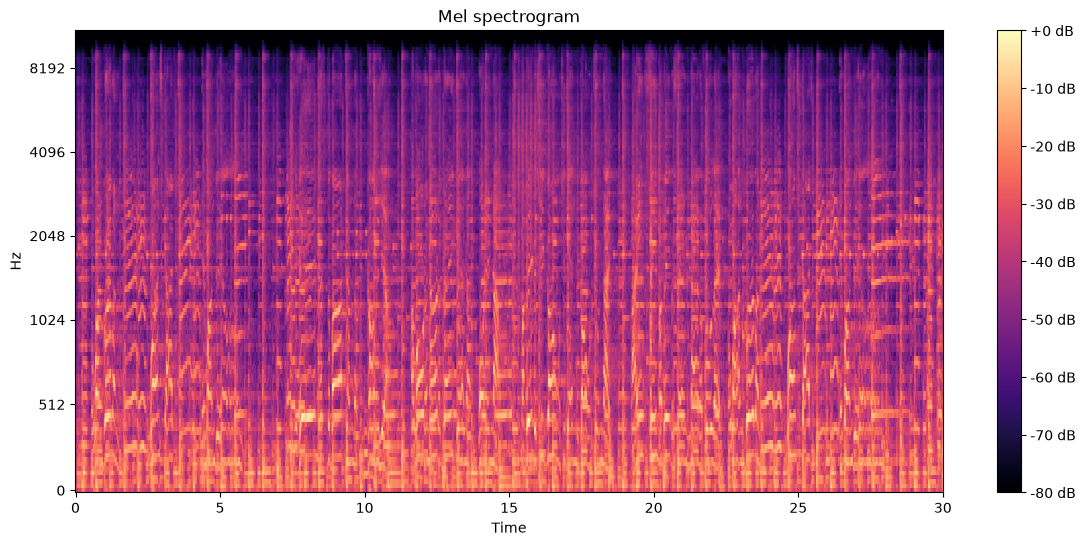

In [114]:
plt.figure(figsize=(14, 6))

librosa.display.specshow(
    mel_db,
    sr = sample_rate,
    hop_length= 512,
    x_axis= "time",
    y_axis= "mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Mel spectrogram")
plt.show()

In [115]:
print(mel_spectrogram.shape)

(128, 1293)


In [116]:
segment_duration = 3 #sec
segment_samples = int(segment_duration * sample_rate)

print("Samples per segment : ", segment_samples)
print("Duration : ", segment_samples / sample_rate, "seconds")

Samples per segment :  66150
Duration :  3.0 seconds


In [117]:
segment = audio[:segment_samples]

print("Segment samples : ", len(segment))
print("Segment duration : ", len(segment)/sample_rate)

Segment samples :  66150
Segment duration :  3.0


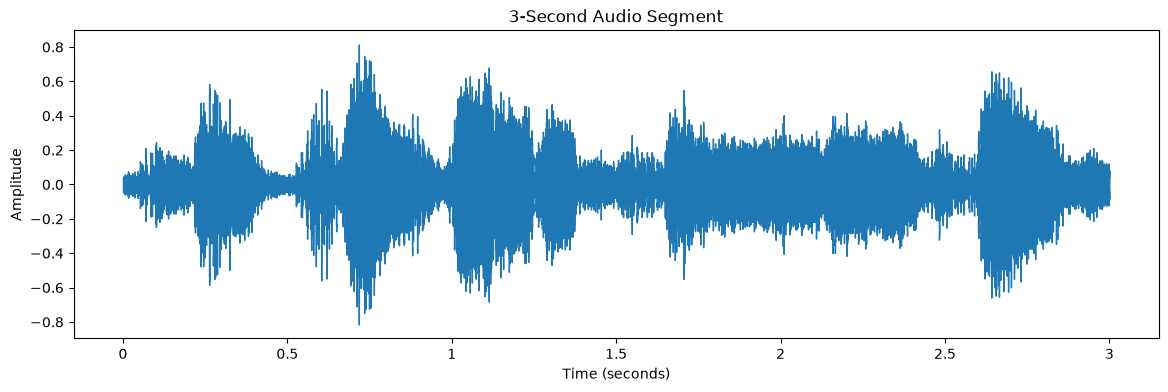

In [118]:
plt.figure(figsize=(14,4))

librosa.display.waveshow(
    segment,
    sr= sample_rate
)

plt.title("3-Second Audio Segment")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

In [119]:
mel_segment = librosa.feature.melspectrogram(
    y= segment,
    sr= sample_rate,
    n_fft = 2048,
    hop_length = 512,
    n_mels = 128
)

mel_segment_db = librosa.power_to_db(
    mel_segment,
    ref = np.max
)

print("Mel spectrogram shape : ", mel_segment_db.shape)

Mel spectrogram shape :  (128, 130)


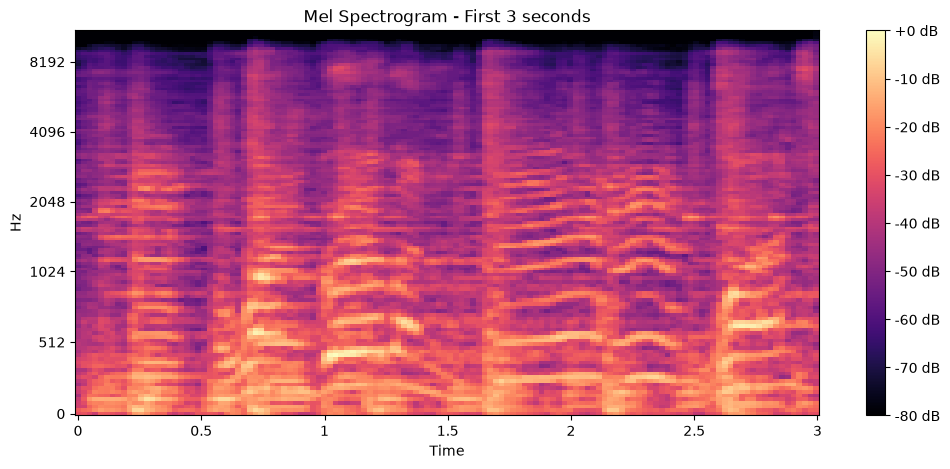

In [120]:
plt.figure(figsize= (12, 5))

librosa.display.specshow(
    mel_segment_db,
    sr=sample_rate,
    hop_length=512,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram - First 3 seconds")
plt.show()

In [121]:
print("Mel spectrogram shape:", mel_segment_db.shape)

Mel spectrogram shape: (128, 130)


In [122]:
segments = []

for start in range(0, len(audio), segment_samples):
    end = start + segment_samples

    segment = audio[start:end]

    if len(segment) == segment_samples:
        segments.append(segment)

print("Number of complete segments : ", len(segments))

Number of complete segments :  10


In [123]:
for i, segment in enumerate(segments):
    print(
        f"Segment {i}:"
        f"{len(segment)} samples, "
        f"{len(segment) / sample_rate:.2f} seconds"
    )

Segment 0:66150 samples, 3.00 seconds
Segment 1:66150 samples, 3.00 seconds
Segment 2:66150 samples, 3.00 seconds
Segment 3:66150 samples, 3.00 seconds
Segment 4:66150 samples, 3.00 seconds
Segment 5:66150 samples, 3.00 seconds
Segment 6:66150 samples, 3.00 seconds
Segment 7:66150 samples, 3.00 seconds
Segment 8:66150 samples, 3.00 seconds
Segment 9:66150 samples, 3.00 seconds


In [124]:
def audio_to_mel_segments(
        audio,
        sample_rate,
        segement_duration=3,
        n_fft=2048,
        hop_length=512,
        n_mels=128
):
    segment_samples = int(segment_duration * sample_rate)

    mel_segments = []

    for start in range(0, len(audio), segment_samples):
        end = start + segment_samples
        segment = audio[start:end]

        if len(segment) != segment_samples:
            continue

        mel = librosa.feature.melspectrogram(
            y=segment,
            sr = sample_rate,
            n_fft= n_fft,
            hop_length= hop_length,
            n_mels = n_mels
        )

        mel_db = librosa.power_to_db(
            mel,
            ref= np.max
        )

        mel_segments.append(mel_db)

    return np.array(mel_segments)

In [125]:
mel_segments = audio_to_mel_segments(
    audio,
    sample_rate
)

print("Shape : ", mel_segments.shape)

Shape :  (10, 128, 130)


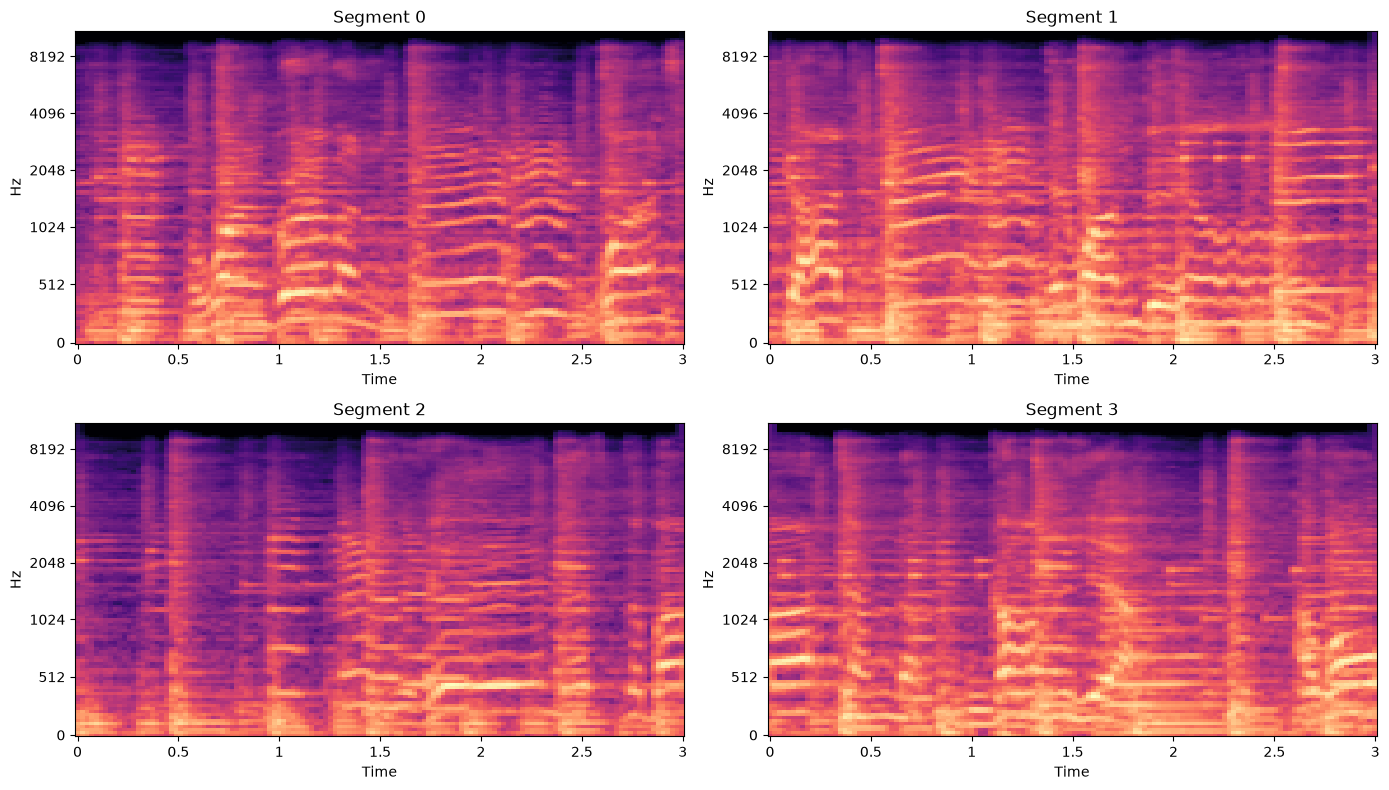

In [126]:
fig, axes = plt.subplots(2, 2, figsize= (14, 8))

for i, ax in enumerate(axes.flat):
    img = librosa.display.specshow(
        mel_segments[i],
        sr= sample_rate,
        hop_length= 512,
        x_axis="time",
        y_axis="mel",
        ax = ax
    )

    ax.set_title(f"Segment {i}")

plt.tight_layout()
plt.show()

In [11]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

In [14]:
genres = [
    "blues",
    "classical",
    "country",
    "disco",
    "hiphop",
    "jazz",
    "metal",
    "pop",
    "reggae",
    "rock"
]

print("Number of genres:", len(genres))

Number of genres: 10


In [15]:
from pathlib import Path

data_dir = Path("../data/raw/genres_original")

files = []

for genre in genres:
    genre_dir = data_dir / genre

    for file in genre_dir.glob("*.wav"):
        files.append({
            "filepath" : str(file),
            "genre" : genre
        })

df = pd.DataFrame(files)

print("Total audio files : ", len(df))
df.head()

Total audio files :  1000


,filepath,genre
0,..\data\raw\genres_original\blues\blues.00000.wav,blues
1,..\data\raw\genres_original\blues\blues.00001.wav,blues
2,..\data\raw\genres_original\blues\blues.00002.wav,blues
3,..\data\raw\genres_original\blues\blues.00003.wav,blues
4,..\data\raw\genres_original\blues\blues.00004.wav,blues


In [16]:
train_df, test_df = train_test_split(df, test_size=0.15, stratify=df["genre"], random_state=42)

In [17]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.1765,
    stratify=train_df["genre"],
    random_state=42
)

In [18]:
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["split"] = "train"
val_df["split"] = "validation"
test_df["split"] = "test"

In [19]:
metadata = pd.concat(
    [train_df, val_df, test_df],
    ignore_index = True
)

print(metadata["split"].value_counts())

split
train         699
validation    151
test          150
Name: count, dtype: int64


In [134]:
print(
    pd.crosstab(
        metadata["genre"],
        metadata["split"]
    )
)

split      test  train  validation
genre                             
blues        15     70          15
classical    15     70          15
country      15     70          15
disco        15     70          15
hiphop       15     70          15
jazz         15     70          15
metal        15     69          16
pop          15     70          15
reggae       15     70          15
rock         15     70          15


In [135]:
metadata.to_csv(
    "../data/metadata/dataset_split.csv",
    index=False
)

In [136]:
def process_audio_file(
        filepath,
        segment_duration = 3,
        n_fft= 2048,
        hop_length= 512,
        n_mels = 128
):
    audio, sr = librosa.load(
        filepath,
        sr = 22050
    )

    segment_samples = int(segment_duration * sr)

    mel_segments = []

    for start in range(0, len(audio), segment_samples):

        end = start + segment_samples
        segment = audio[start:end]

        if len(segment) != segment_samples:
            continue

        mel = librosa.feature.melspectrogram(
            y= segment,
            sr=sr,
            n_fft= n_fft,
            hop_length = hop_length,
            n_mels = n_mels
        )

        mel_db = librosa.power_to_db(
            mel,
            ref= np.max
        )

        mel_segments.append(mel_db)

    return np.array(mel_segments)

In [137]:
test_file = metadata.iloc[0]["filepath"]

mel_segments = process_audio_file(test_file)

print("File : ", test_file)
print("Shape : ", mel_segments.shape)

File :  ..\data\raw\genres_original\rock\rock.00002.wav
Shape :  (10, 128, 130)


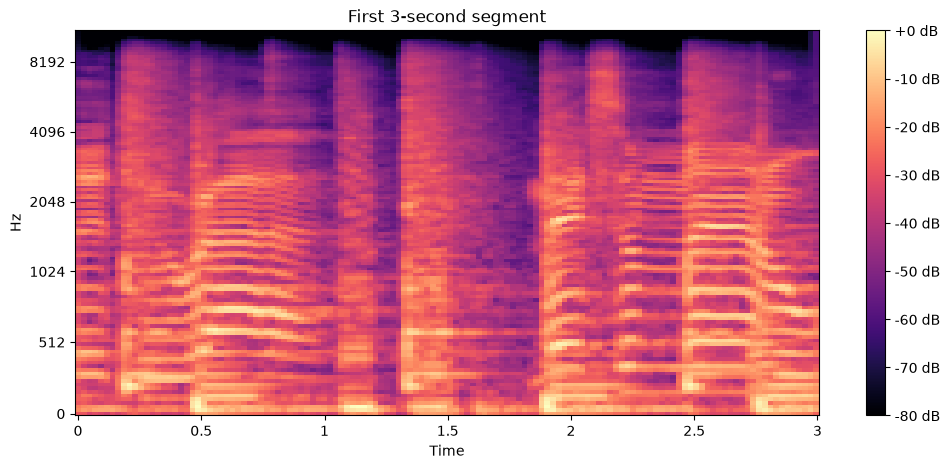

In [138]:
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mel_segments[0],
    sr = 22050,
    hop_length= 512,
    x_axis= "time",
    y_axis= "mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("First 3-second segment")
plt.show()

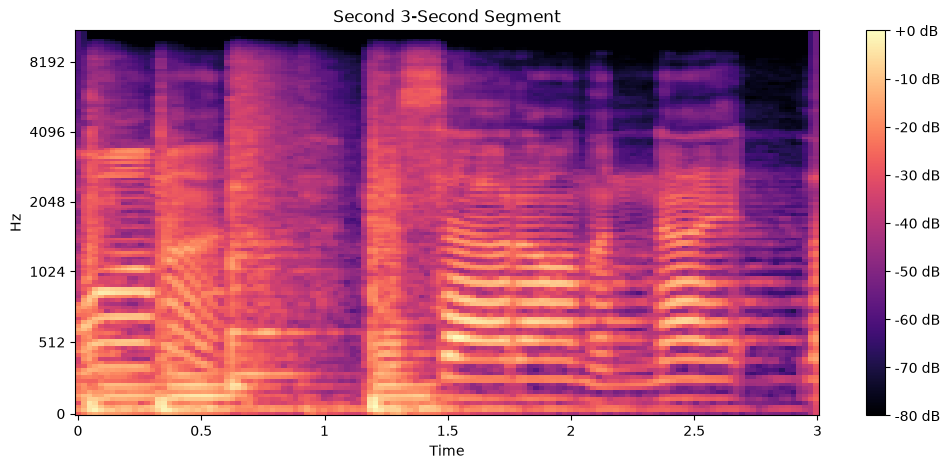

In [139]:
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mel_segments[1],
    sr=22050,
    hop_length=512,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Second 3-Second Segment")
plt.show()

In [140]:
print("Minimum : ", mel_segments.min())
print("Maximum : ", mel_segments.max())
print("Mean : ", mel_segments.mean())
print("Standard deviation : ", mel_segments.std())

Minimum :  -80.0
Maximum :  0.0
Mean :  -41.212578
Standard deviation :  15.595637


In [141]:
mel_normalized = np.clip(
    mel_segments,
    -80,
    0
)

mel_normalized = (mel_normalized + 80) / 80

In [142]:
print("Minimum : ", mel_normalized.min())
print("Maximum : ", mel_normalized.max())

Minimum :  0.0
Maximum :  1.0


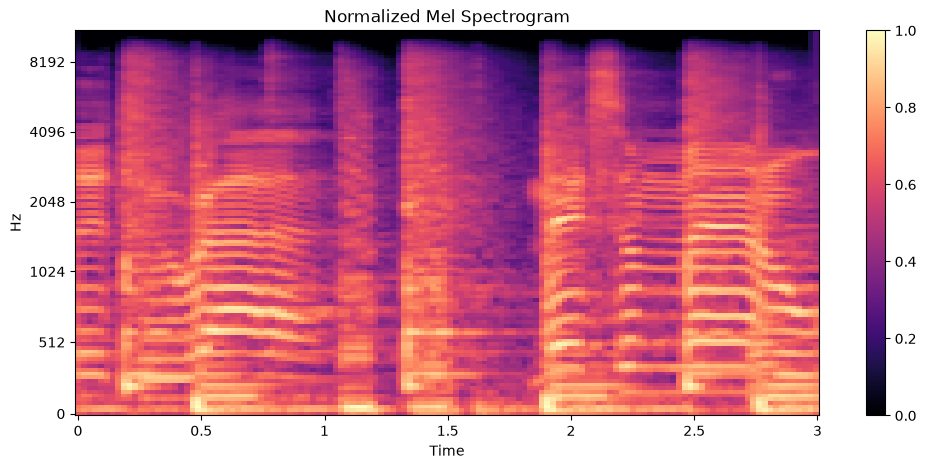

In [143]:
plt.figure(figsize=(12,5))

librosa.display.specshow(
    mel_normalized[0],
    sr = 22050,
    hop_length= 512,
    x_axis="time",
    y_axis= "mel"
)

plt.colorbar()
plt.title("Normalized Mel Spectrogram")
plt.show()

In [144]:
test_file = metadata.iloc[0]["filepath"]

audio, sr = load_audio(test_file)

mel_segments = audio_to_mel_segments(
    audio,
    sr
)

print("Audio shape : ", audio.shape)
print("Sample rate : ", sr)
print("Mel segments shape : ", mel_segments.shape)
print("Minimum : ", mel_segments.min())
print("Maximum : ", mel_segments.max())

Audio shape :  (661794,)
Sample rate :  22050
Mel segments shape :  (10, 128, 130)
Minimum :  -80.0
Maximum :  0.0


In [145]:
from pathlib import Path
import numpy as np

output_dir = Path("../data/processed/train/blues")
output_dir.mkdir(parents=True, exist_ok= True)

output_path = output_dir / "blues.0000.npy"

np.save(
    output_path,
    mel_segments.astype(np.float32)
)

print("Saved to : ", output_path)

Saved to :  ..\data\processed\train\blues\blues.0000.npy


In [146]:
loaded = np.load(output_path)

print("Loaded shape : ", loaded.shape)
print("Minimum : ", loaded.min())
print("Maximum : ", loaded.max())

Loaded shape :  (10, 128, 130)
Minimum :  -80.0
Maximum :  0.0


In [147]:
test_file = metadata.iloc[0]["filepath"]

output_path = process_and_save_file(
    filepath= test_file,
    output_dir= "../data/processed/test"
)

print("Saved : ", output_path)

Saved :  ..\data\processed\test\rock.00002.npy


In [148]:
loaded = np.load(output_path)

print("Shape:", loaded.shape)
print("Minimum:", loaded.min())
print("Maximum:", loaded.max())
print("Data type:", loaded.dtype)

Shape: (10, 128, 130)
Minimum: 0.0
Maximum: 1.0
Data type: float32


In [149]:
import importlib
import src.preprocessing

importlib.reload(src.preprocessing)

<module 'src.preprocessing' from 'c:\\Users\\Mohal\\Documents\\Projects\\music-genre-classifier\\notebooks\\..\\src\\preprocessing.py'>

In [150]:
from src.preprocessing import process_dataset

In [151]:
print(metadata.shape)
print(metadata["split"].value_counts())
print(metadata["genre"].value_counts())

(1000, 3)
split
train         699
validation    151
test          150
Name: count, dtype: int64
genre
rock         100
country      100
jazz         100
metal        100
disco        100
blues        100
hiphop       100
classical    100
reggae       100
pop          100
Name: count, dtype: int64


In [152]:
# failed_files = process_dataset(metadata)

In [153]:
# print("Failed files : ")

# for file in failed_files:
#     print(file)

# print("Number of failed files : ", len(failed_files))

In [154]:
# data = np.load(train_files[0][0])

# print("Shape:", data.shape)
# print("Minimum:", data.min())
# print("Maximum:", data.max())

In [155]:
from pathlib import Path

processed_dir = Path("../data/processed")

for split in ["train", "validation", "test"]:
    files = list((processed_dir / split).rglob("*.npy"))
    print(f"{split}: {len(files)} files")

train: 700 files
validation: 150 files
test: 151 files


In [156]:
for split in ["train", "validation", "test"]:
    print(f"\n{split.upper()}")

    for genre in genres:
        genre_dir = processed_dir / split / genre
        count = len(list(genre_dir.glob("*.npy")))

        print(f"{genre:10s}: {count}")


TRAIN
blues     : 71
classical : 70
country   : 70
disco     : 70
hiphop    : 70
jazz      : 70
metal     : 69
pop       : 70
reggae    : 70
rock      : 70

VALIDATION
blues     : 15
classical : 15
country   : 15
disco     : 15
hiphop    : 15
jazz      : 14
metal     : 16
pop       : 15
reggae    : 15
rock      : 15

TEST
blues     : 15
classical : 15
country   : 15
disco     : 15
hiphop    : 15
jazz      : 15
metal     : 15
pop       : 15
reggae    : 15
rock      : 15


In [157]:
sample_file = next(
    (processed_dir / "train").rglob("*.npy")
)

print("File:", sample_file)

File: ..\data\processed\train\blues\blues.0000.npy


In [158]:
sample = np.load(sample_file)

print("Shape:", sample.shape)
print("Dtype:", sample.dtype)
print("Min:", sample.min())
print("Max:", sample.max())

Shape: (10, 128, 130)
Dtype: float32
Min: -80.0
Max: 0.0


In [159]:
import sys
sys.path.append("../")

from src.dataset import create_dataset

In [160]:
train_dataset = create_dataset(
    split= "train",
    batch_size= 32,
    shuffle = True
)

In [161]:
X_batch, y_batch = next(iter(train_dataset))

print("X shape : ", X_batch.shape)
print("y shape : ", y_batch.shape)

X shape :  (32, 128, 130, 1)
y shape :  (32,)


In [162]:
print(y_batch.numpy())

[0 0 0 0 0 1 1 0 0 0 1 1 0 1 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1]


In [163]:
from src.dataset import GENRES

for label in y_batch.numpy():
    print(label, GENRES[label])

0 blues
0 blues
0 blues
0 blues
0 blues
1 classical
1 classical
0 blues
0 blues
0 blues
1 classical
1 classical
0 blues
1 classical
0 blues
0 blues
1 classical
0 blues
0 blues
0 blues
1 classical
0 blues
0 blues
0 blues
0 blues
1 classical
0 blues
0 blues
0 blues
0 blues
0 blues
1 classical


In [164]:
from src.model import build_cnn

model = build_cnn()

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,394 (16.36 MB)

 Trainable params: 4,288,394 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [165]:
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [166]:
val_dataset = create_dataset(
    split = "validation",
    batch_size=32,
    shuffle= False
)

test_dataset = create_dataset(
    split = "test",
    batch_size= 32,
    shuffle = False
)

In [167]:
X_val, y_val = next(iter(val_dataset))
X_test, y_test = next(iter(test_dataset))

print("Validation : ")
print("X : ", X_val.shape)
print("y : ", y_val.shape)

print("\nTest : ")
print("X : ", X_test.shape)
print("y : ", y_test.shape)

Validation : 
X :  (32, 128, 130, 1)
y :  (32,)

Test : 
X :  (32, 128, 130, 1)
y :  (32,)


In [168]:
history = model.fit(
    train_dataset,
    validation_data = val_dataset,
    epochs = 20
)

Epoch 1/20


c:\Users\Mohal\Documents\Projects\music-genre-classifier\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


    219/Unknown 41s 178ms/step - accuracy: 0.3563 - loss: 1.8056

c:\Users\Mohal\Documents\Projects\music-genre-classifier\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


219/219 ━━━━━━━━━━━━━━━━━━━━ 44s 191ms/step - accuracy: 0.3563 - loss: 1.8056 - val_accuracy: 0.1634 - val_loss: 3.1620
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 41s 187ms/step - accuracy: 0.4112 - loss: 1.6473 - val_accuracy: 0.1414 - val_loss: 2.7294
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 51s 234ms/step - accuracy: 0.4973 - loss: 1.5193 - val_accuracy: 0.2548 - val_loss: 2.7256
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 58s 265ms/step - accuracy: 0.5626 - loss: 1.2383 - val_accuracy: 0.2115 - val_loss: 2.6794
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 66s 299ms/step - accuracy: 0.5631 - loss: 1.2189 - val_accuracy: 0.1988 - val_loss: 3.0788
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 68s 308ms/step - accuracy: 0.5715 - loss: 1.2450 - val_accuracy: 0.2221 - val_loss: 2.9315
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 59s 269ms/step - accuracy: 0.5971 - loss: 1.1932 - val_accuracy: 0.2168 - val_loss: 2.9880
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 58s 263ms/step - accuracy: 0.6018 - loss: 1.2344 - val

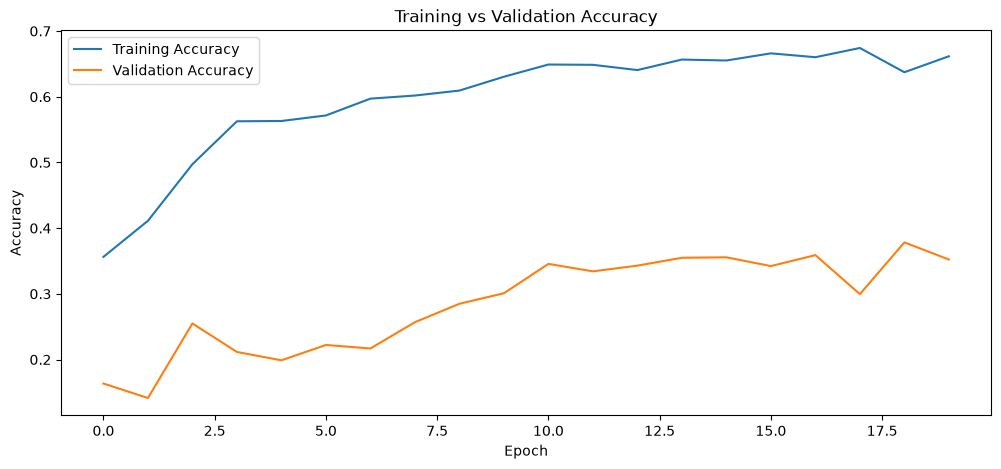

In [169]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

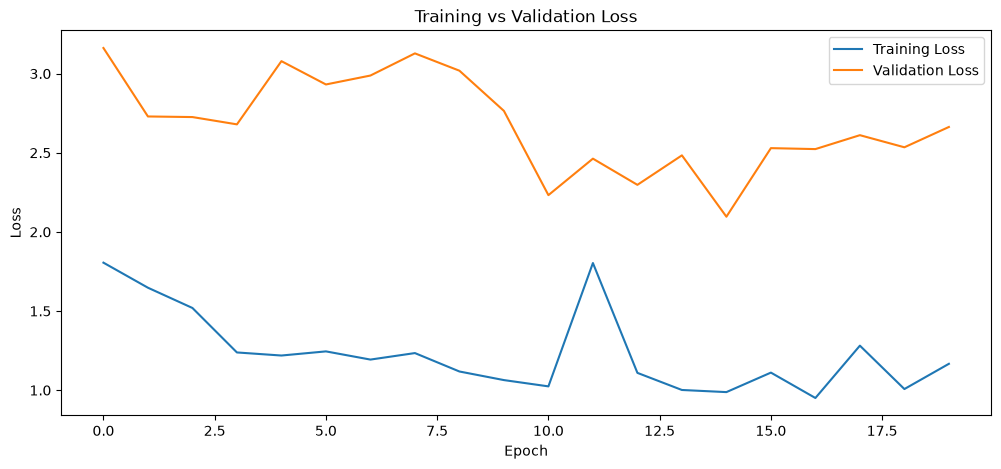

In [170]:
plt.figure(figsize=(12, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [171]:
best_epoch = np.argmax(history.history["val_accuracy"]) + 1
best_val_accuracy = max(history.history["val_accuracy"])

print("Best epoch:", best_epoch)
print("Best validation accuracy:", best_val_accuracy)

Best epoch: 19
Best validation accuracy: 0.37825217843055725


In [172]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.3413 - loss: 2.7422
Test loss: 2.7421681880950928
Test accuracy: 0.3413333296775818


In [173]:
import sys
sys.path.append("../")

from src.dataset import get_processed_files

In [174]:
import math

train_files = get_processed_files(
    split = "train"
)

val_files = get_processed_files(
    split = "validation"
)

test_files = get_processed_files(
    split = "test"
)

print("Train files: ", len(train_files))
print("Validation files: ", len(val_files))
print("Test files: ", len(test_files))

Train files:  700
Validation files:  150
Test files:  150


In [175]:
def count_segments(files):
    total = 0

    for filepath, _ in files:
        total += len(np.load(filepath))

    return total


train_segments = count_segments(train_files)
val_segments = count_segments(val_files)
test_segments = count_segments(test_files)

print("Train segments:", train_segments)
print("Validation segments:", val_segments)
print("Test segments:", test_segments)

Train segments: 6992
Validation segments: 1499
Test segments: 1500


In [176]:
batch_size = 32

train_steps = math.ceil(train_segments / batch_size)
val_steps = math.ceil(val_segments / batch_size)
test_steps = math.ceil(test_segments / batch_size)

print("Train steps:", train_steps)
print("Validation steps:", val_steps)
print("Test steps:", test_steps)

Train steps: 219
Validation steps: 47
Test steps: 47


In [177]:
import importlib
import src.dataset

importlib.reload(src.dataset)

from src.dataset import create_dataset, get_processed_files

In [178]:
train_dataset = create_dataset(
    split="train",
    batch_size=32,
    shuffle=True,
    repeat=True
)

val_dataset = create_dataset(
    split="validation",
    batch_size=32,
    shuffle=False,
    repeat=False
)

test_dataset = create_dataset(
    split="test",
    batch_size=32,
    shuffle=False,
    repeat=False
)

In [179]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    steps_per_epoch=train_steps
)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 62s 284ms/step - accuracy: 0.6801 - loss: 0.9278 - val_accuracy: 0.4009 - val_loss: 2.3129
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 66s 299ms/step - accuracy: 0.6909 - loss: 0.8669 - val_accuracy: 0.4056 - val_loss: 2.1824
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 62s 285ms/step - accuracy: 0.7070 - loss: 0.8626 - val_accuracy: 0.4236 - val_loss: 2.2227
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 58s 263ms/step - accuracy: 0.7293 - loss: 0.8076 - val_accuracy: 0.4410 - val_loss: 2.0675
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 57s 262ms/step - accuracy: 0.7313 - loss: 0.7816 - val_accuracy: 0.3976 - val_loss: 2.1099
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 58s 266ms/step - accuracy: 0.7369 - loss: 0.7551 - val_accuracy: 0.4183 - val_loss: 2.1112
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 60s 272ms/step - accuracy: 0.7422 - loss: 0.7422 - val_accuracy: 0.4243 - val_loss: 1.8619
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 57s 261ms/step - accuracy: 0.7382 - loss: 0

In [180]:
import inspect
from src.preprocessing import audio_to_mel_segments

print(inspect.getsource(audio_to_mel_segments))

def audio_to_mel_segments(
        audio,
        sample_rate,
        segment_duration = 3,
        n_fft = 2048,
        hop_length = 512,
        n_mels = 128
):
    segment_samples = int(segment_duration * sample_rate)

    mel_segments = []

    for start in range(0, len(audio), segment_samples):
        end = start + segment_samples
        segment = audio[start:end]

        if len(segment) != segment_samples:
            continue

        mel = librosa.feature.melspectrogram(
            y= segment,
            sr = sample_rate,
            n_fft = n_fft,
            hop_length= hop_length,
            n_mels = n_mels
        )

        mel_db = librosa.power_to_db(
            mel,
            ref = np.max
        )

        mel_db = np.clip(
            mel_db,
            -80,
            0
        )

        mel_normalized = (mel_db + 80) / 80

        mel_segments.append(mel_normalized)

    return np.array(mel_segments)



In [181]:
import importlib
import src.preprocessing

importlib.reload(src.preprocessing)

from src.preprocessing import load_audio, audio_to_mel_segments

In [3]:
import importlib
import src.preprocessing

importlib.reload(src.preprocessing)

from src.preprocessing import (
    load_audio,
    audio_to_mel_segments,
    process_and_save_file,
    process_dataset
)

In [20]:
test_file = metadata.iloc[0]["filepath"]

audio, sr = load_audio(test_file)

mel_segments = audio_to_mel_segments(
    audio,
    sr
)

print("Audio shape:", audio.shape)
print("Sample rate:", sr)
print("Mel segments shape:", mel_segments.shape)
print("Minimum:", mel_segments.min())
print("Maximum:", mel_segments.max())

Audio shape: (661794,)
Sample rate: 22050
Mel segments shape: (39, 128, 65)
Minimum: 0.0
Maximum: 1.0


In [21]:
failed_files = process_dataset(
    metadata,
    output_root="../data/processed"
)

print("Failed files:", len(failed_files))

Processing audio:  83%|████████▎ | 831/1000 [03:27<00:26,  6.49it/s]


Failed: ..\data\raw\genres_original\jazz\jazz.00054.wav
Error: Error opening '..\\data\\raw\\genres_original\\jazz\\jazz.00054.wav': Format not recognised.


Processing audio: 100%|██████████| 1000/1000 [04:07<00:00,  4.03it/s]

Failed files: 1


In [22]:
import importlib

import src.dataset
import src.model

importlib.reload(src.dataset)
importlib.reload(src.model)

from src.dataset import create_dataset
from src.model import build_cnn

In [23]:
train_dataset = create_dataset(
    split="train",
    batch_size=32,
    shuffle=True,
    repeat=True
)

val_dataset = create_dataset(
    split="validation",
    batch_size=32,
    shuffle=False,
    repeat=False
)

test_dataset = create_dataset(
    split="test",
    batch_size=32,
    shuffle=False,
    repeat=False
)

In [24]:
import numpy as np
from src.dataset import get_processed_files


def count_segments(split):

    files = get_processed_files(
        split=split
    )

    total = 0

    for filepath, label in files:

        total += len(
            np.load(filepath)
        )

    return total


train_segments = count_segments("train")
val_segments = count_segments("validation")
test_segments = count_segments("test")

print("Train segments:", train_segments)
print("Validation segments:", val_segments)
print("Test segments:", test_segments)

Train segments: 27253
Validation segments: 5849
Test segments: 5850


In [25]:
import math

train_steps = math.ceil(
    train_segments / 32
)

val_steps = math.ceil(
    val_segments / 32
)

test_steps = math.ceil(
    test_segments / 32
)

print(train_steps)
print(val_steps)
print(test_steps)

852
183
183


In [26]:
from tensorflow import keras

In [27]:
model = build_cnn()

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 65, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 65, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 8, 256)     │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 8, 256)     │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,946 (1.62 MB)

 Trainable params: 422,986 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [28]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [29]:
callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

In [30]:
history = model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=30,

    steps_per_epoch=train_steps,

    validation_steps=val_steps,

    callbacks=callbacks
)

Epoch 1/30


c:\Users\Mohal\Documents\Projects\music-genre-classifier\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


852/852 ━━━━━━━━━━━━━━━━━━━━ 194s 225ms/step - accuracy: 0.8452 - loss: 0.6874 - val_accuracy: 0.1067 - val_loss: 8.6120
Epoch 2/30
852/852 ━━━━━━━━━━━━━━━━━━━━ 240s 281ms/step - accuracy: 0.8526 - loss: 0.6194 - val_accuracy: 0.1081 - val_loss: 8.9449
Epoch 3/30
852/852 ━━━━━━━━━━━━━━━━━━━━ 229s 268ms/step - accuracy: 0.8583 - loss: 0.5592 - val_accuracy: 0.1034 - val_loss: 11.2785
Epoch 4/30
852/852 ━━━━━━━━━━━━━━━━━━━━ 234s 275ms/step - accuracy: 0.8677 - loss: 0.4969 - val_accuracy: 0.1091 - val_loss: 9.7325
Epoch 5/30
852/852 ━━━━━━━━━━━━━━━━━━━━ 231s 271ms/step - accuracy: 0.8645 - loss: 0.5002 - val_accuracy: 0.1005 - val_loss: 27.0167
Epoch 6/30
852/852 ━━━━━━━━━━━━━━━━━━━━ 226s 265ms/step - accuracy: 0.8664 - loss: 0.4781 - val_accuracy: 0.1334 - val_loss: 9.3134


In [31]:
test_loss, test_accuracy = model.evaluate(
    test_dataset,
    steps=test_steps
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

183/183 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.0998 - loss: 8.5711
Test loss: 8.571122169494629
Test accuracy: 0.0998290628194809
